In [1]:
####################################################################
##  First part: import libraries                                  #
##################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  
import os
import rasterio
import rasterio.features
import rasterio.warp
from osgeo import gdal
from matplotlib import pyplot
from rasterio.plot import show 
import geopandas as gpd
from osgeo import ogr, osr
import math

import re

from rasterstats import zonal_stats

c:\Users\giambelluca.144055\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\giambelluca.144055\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
from pandas.core.computation.check import NUMEXPR_INSTALLED

In [2]:
Catalunia=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Resultados_extraccion\\Catalunia\\Stat_Catalunia_MFE85.csv')
Navarra=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Resultados_extraccion\\Navarra\\Stat_Navarra_MFE85.csv')
Valencia=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Resultados_extraccion\\Valencia\\Stat_Valencia_MFE85.csv')

In [3]:
cat=Catalunia.copy()
nav=Navarra.copy()
val=Valencia.copy()
cat['CCAA']='C'
nav['CCAA']='N'
val['CCAA']='V'

In [4]:
df_cat=gpd.read_file('D:\giambelluca.144055\Incendios\Proyecto\Capas\MFE_1985_unidos\Capa_intermedia\BOSQUES_Catalunia_MFE85_4326.shp')
df_cat['ID_total']=df_cat['ID_total'].astype(np.float32)


df_nav=gpd.read_file('D:\giambelluca.144055\Incendios\Proyecto\Capas\MFE_1985_unidos\Capa_intermedia\BOSQUES_Navarra_MFE85_4326.shp')
df_nav['ID_total']=df_nav['ID_total'].astype(np.float32)

df_val=gpd.read_file('D:\giambelluca.144055\Incendios\Proyecto\Capas\MFE_1985_unidos\Capa_intermedia\BOSQUES_Valencia_MFE85_4326.shp')
df_val['ID_total']=df_val['ID_total'].astype(np.float32)

In [ ]:
len(cat)

In [5]:
df_cat=df_cat.dissolve(by='ID_total')
df_nav=df_nav.dissolve(by='ID_total')
df_val=df_val.dissolve(by='ID_total')

In [6]:
union_cat=pd.merge(cat, df_cat, left_on='ID_forest',right_on='ID_total', how='inner')
union_nav=pd.merge(nav, df_nav, left_on='ID_forest',right_on='ID_total', how='inner')
union_val=pd.merge(val, df_val, left_on='ID_forest',right_on='ID_total', how='inner')

In [10]:
union_cat.columns

Index(['ID_forest', 'Magnitude', 'Row', 'Severity', 'Slope', 'Aspect', 'Face',
       'TRSI', 'Height', 'North', 'East', 'CCAA', 'geometry', 'Especie1',
       'MFE_1985_R', 'layer', 'ID', 'FECHA', 'Nombre', 'Label', 'Label_MFEa'],
      dtype='object')

In [ ]:
union_nav

In [ ]:
union_val.columns

In [7]:
union_cat.drop(columns=['layer', 'Nombre','Label_MFEa'], inplace=True)
union_nav.drop(columns=['DesTipEstr', 'Nombre','Label_MFEa'], inplace=True)
union_val.drop(columns=['Nombre','Label_MFEa'], inplace=True)


In [10]:
union_cat.columns

Index(['ID_forest', 'Magnitude', 'Row', 'Severity', 'Slope', 'Aspect', 'Face',
       'TRSI', 'Height', 'North', 'East', 'CCAA', 'geometry', 'Especie1',
       'MFE_1985_R', 'ID', 'FECHA', 'Label'],
      dtype='object')

In [11]:
union_val.columns=['ID_forest', 'Magnitude', 'Row', 'Severity', 'Slope', 'Aspect', 'Face',
       'TRSI', 'Height', 'North', 'East', 'CCAA', 'geometry', 'Especie1',
       'MFE_1985_R', 'ID', 'Label', 'FECHA']

In [12]:
DF = pd.concat([union_cat, union_nav, union_val], ignore_index=True)
copia=DF.copy()

In [13]:
print('Porcentaje de pixeles con magnitud menor a 0: ',((len(DF.loc[(DF['Magnitude']<-0.1)]))/(len(DF)))*100)

Porcentaje de pixeles con magnitud menor a 0:  73.53035822399048


In [14]:
DF=DF.loc[(DF['Magnitude']<-0.1)]

In [15]:
len(DF)

1156209

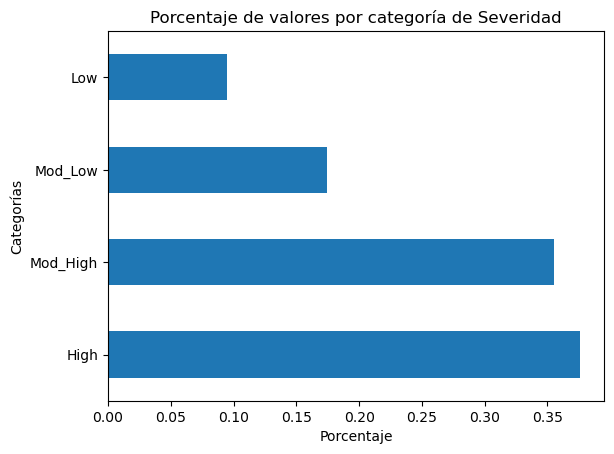

In [16]:
porcentajes = DF['Severity'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por categoría de Severidad')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

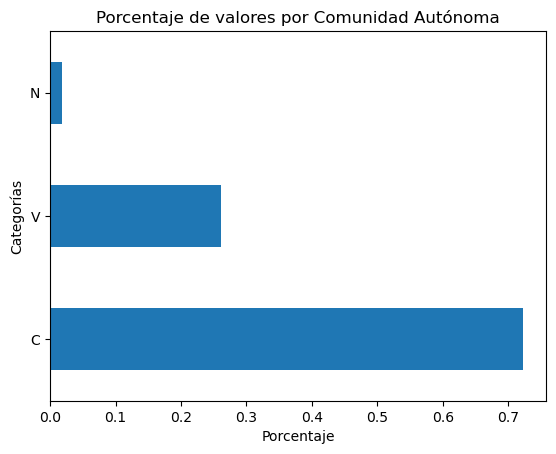

In [17]:
porcentajes = DF['CCAA'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por Comunidad Autónoma')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

In [18]:
cuartiles = DF['Slope'].quantile([0.25,0.5,0.75])

# Mostrar los cuartiles
print(cuartiles)

0.25     9.515857
0.50    14.917929
0.75    21.424613
Name: Slope, dtype: float64


In [19]:
DF.loc[(DF['Slope'] >20), ['Range_S']] = ['>20']
# DF.loc[(DF['Slope'] >25)&(DF['Slope']<=35), ['Range_S']] = ['25-35']
DF.loc[(DF['Slope'] >15)&(DF['Slope']<=20), ['Range_S']] = ['15-20']
DF.loc[(DF['Slope'] >10)&(DF['Slope']<=15), ['Range_S']] = ['10-15']
DF.loc[(DF['Slope'] <=10), ['Range_S']] = ['<10']

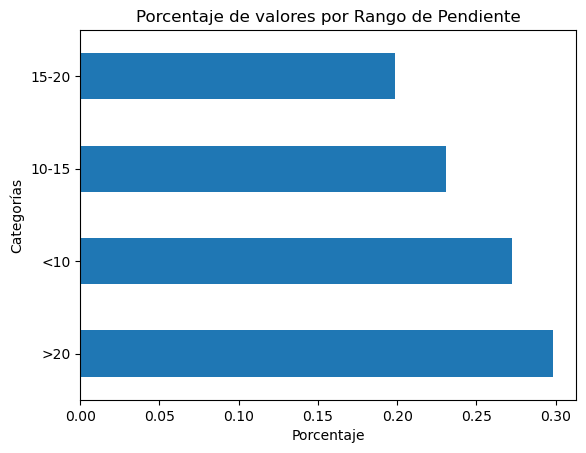

In [20]:
porcentajes = DF['Range_S'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por Rango de Pendiente')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

In [21]:
cuartiles = DF['Height'].quantile([0.25,0.5,0.75])

# Mostrar los cuartiles
print(cuartiles)

0.25    318.0
0.50    529.0
0.75    673.0
Name: Height, dtype: float64


In [22]:
DF.loc[(DF['Height'] >700), ['Range_H']] = ['>700']
DF.loc[(DF['Height'] >550)&(DF['Height']<=700), ['Range_H']] = ['550-700']
DF.loc[(DF['Height'] >350)&(DF['Height']<=550), ['Range_H']] = ['350-550']
DF.loc[(DF['Height'] <=350), ['Range_H']] = ['<350']

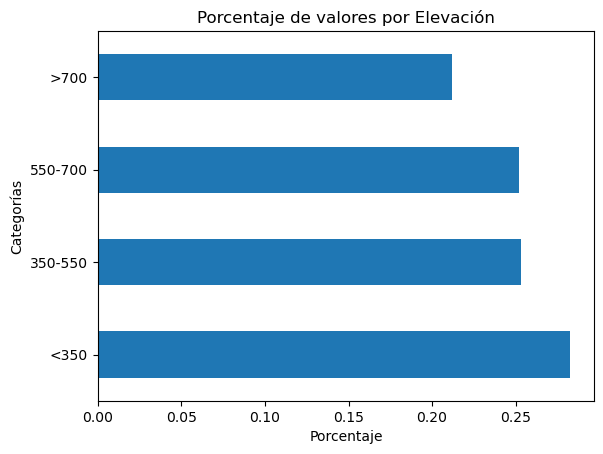

In [23]:
porcentajes = DF['Range_H'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por Elevación')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

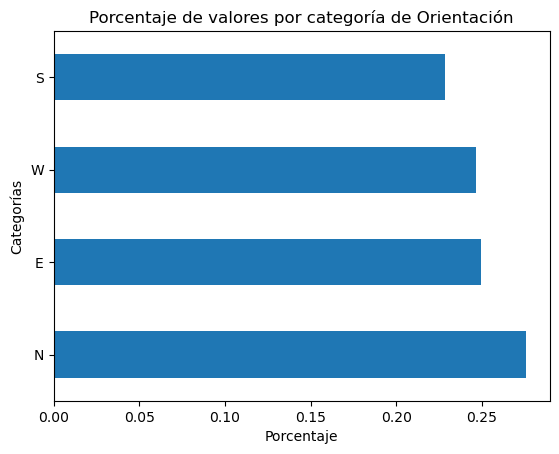

In [24]:
porcentajes = DF['Face'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por categoría de Orientación')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

<AxesSubplot:>

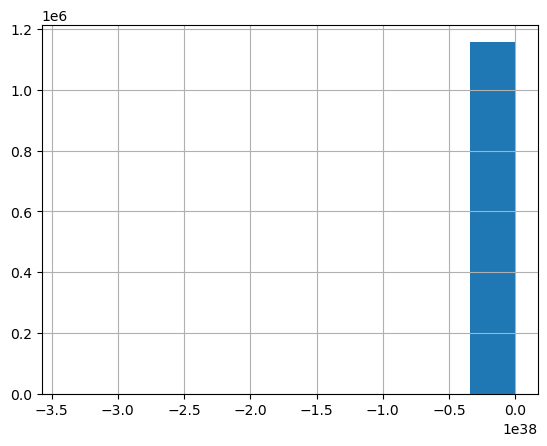

In [25]:
DF['North'].hist()
# porcentajes = DF['North'].value_counts(normalize=True)

# porcentajes.plot(kind='barh')
# plt.title('Porcentaje de valores por Norte')
# plt.xlabel('Porcentaje')
# plt.ylabel('Categorías')
# plt.show()

<AxesSubplot:>

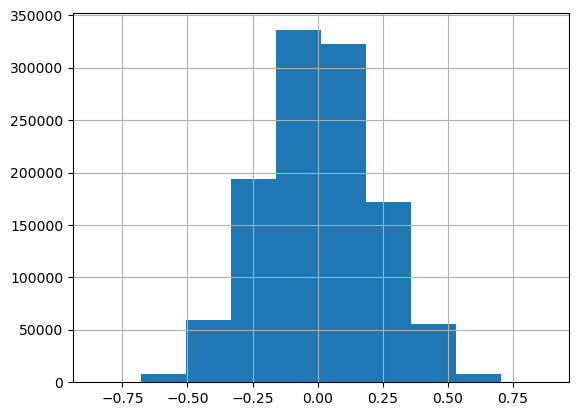

In [26]:
DF['East'].hist()

<AxesSubplot:>

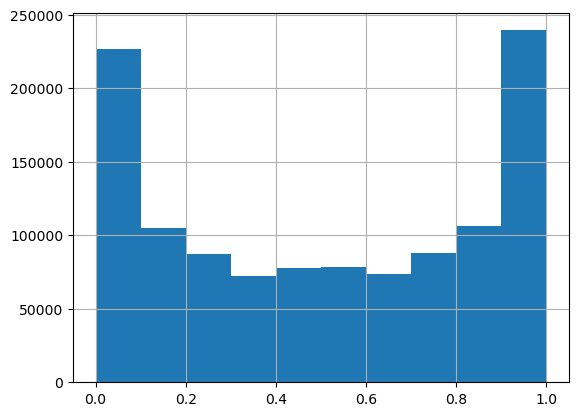

In [27]:
DF['TRSI'].hist()


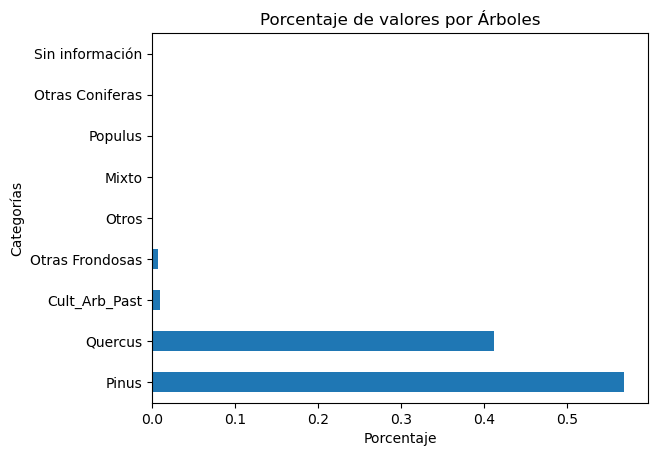

In [28]:
porcentajes = DF['Label'].value_counts(normalize=True)

porcentajes.plot(kind='barh')
plt.title('Porcentaje de valores por Árboles')
plt.xlabel('Porcentaje')
plt.ylabel('Categorías')
plt.show()

In [32]:
porcentajes_por_grupo = DF['Label'].value_counts(normalize=False)

# Mostrar los resultados
print(porcentajes_por_grupo)

Label
Pinus              658414
Quercus            476428
Cult_Arb_Past       11711
Otras Frondosas      8619
Otros                 876
Mixto                  65
Populus                54
Otras Coniferas        41
Sin información         1
Name: count, dtype: int64


In [69]:
# nueva_ruta = 'D:\\giambelluca.144055\\Incendios\\Proyecto\\Statis_CCAA\\Stat_Todo_MFE85_separado.csv'
# DF.to_csv(nueva_ruta, index=False)

In [265]:
resultados = DF.groupby(['Severity', 'Face', 'Range_S', 'Range_H'])['ID_forest'].count()
primeros_256_resultados = resultados.reset_index()
primeros_256_resultados
# primeros_256_resultados.to_csv(nueva_ruta, index=False)

,Severity,Face,Range_S,Range_H,ID_forest
0,High,E,10-15,350-550,4783
1,High,E,10-15,550-700,6354
2,High,E,10-15,<350,5614
3,High,E,10-15,>700,3206
4,High,E,15-20,350-550,4503
...,...,...,...,...,...
251,Mod_Low,W,<10,>700,2855
252,Mod_Low,W,>20,350-550,4006
253,Mod_Low,W,>20,550-700,3312
254,Mod_Low,W,>20,<350,2476


In [94]:
DF

,ID_forest,Magnitude,Row,Severity,Slope,Aspect,Face,TRSI,Height,North,East,CCAA,geometry,Especie1,MFE_1985_R,ID,FECHA,Label,Range_S,Range_H
2,22534.0,-0.596560,[5074 6373],Mod_High,26.408007,299.273500,W,0.106786,499.0,0.217479,-0.387962,C,"MULTIPOLYGON (((1.71797 41.62318, 1.71793 41.6...",Juniperus oxycedrus,534,22_C,1986,Cult_Arb_Past,>20,350-550
3,22534.0,-0.567480,[5074 6374],Mod_High,10.206794,302.645540,W,0.125632,507.0,0.095590,-0.149208,C,"MULTIPOLYGON (((1.71797 41.62318, 1.71793 41.6...",Juniperus oxycedrus,534,22_C,1986,Cult_Arb_Past,10-15,350-550
5,22534.0,-0.632151,[5075 6371],Mod_High,26.779620,300.876900,W,0.115581,497.0,0.231226,-0.386703,C,"MULTIPOLYGON (((1.71797 41.62318, 1.71793 41.6...",Juniperus oxycedrus,534,22_C,1986,Cult_Arb_Past,>20,350-550
6,22534.0,-0.632151,[5075 6372],Mod_High,26.779620,300.876900,W,0.115581,497.0,0.231226,-0.386703,C,"MULTIPOLYGON (((1.71797 41.62318, 1.71793 41.6...",Juniperus oxycedrus,534,22_C,1986,Cult_Arb_Past,>20,350-550
7,22534.0,-0.458608,[5075 6373],Mod_High,15.602646,301.447000,W,0.118782,508.0,0.140322,-0.229459,C,"MULTIPOLYGON (((1.71797 41.62318, 1.71793 41.6...",Juniperus oxycedrus,534,22_C,1986,Cult_Arb_Past,15-20,350-550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572419,591224.0,-0.244098,[6630 3223],Low,12.977186,10.446867,N,0.665424,882.0,0.220841,0.040719,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700
1572420,591224.0,-0.347412,[6630 3224],Mod_Low,13.231969,15.459847,N,0.706022,881.0,0.220612,0.061015,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700
1572421,591224.0,-0.347412,[6630 3225],Mod_Low,12.821540,5.267209,N,0.622151,879.0,0.220978,0.020372,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700
1572422,591224.0,-0.375358,[6630 3226],Mod_Low,15.224509,17.883074,N,0.725100,880.0,0.249914,0.080639,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,15-20,>700


In [95]:
resultados = DF.groupby(['Label','Severity', 'Face', 'Range_S', 'Range_H'])['ID_forest'].count()
primeros_256_resultados = resultados.reset_index()
primeros_256_resultados

,Label,Severity,Face,Range_S,Range_H,ID_forest
0,Cult_Arb_Past,High,E,10-15,350-550,27
1,Cult_Arb_Past,High,E,10-15,550-700,26
2,Cult_Arb_Past,High,E,10-15,<350,36
3,Cult_Arb_Past,High,E,10-15,>700,13
4,Cult_Arb_Past,High,E,15-20,350-550,28
...,...,...,...,...,...,...
1137,Quercus,Mod_Low,W,>20,550-700,548
1138,Quercus,Mod_Low,W,>20,<350,327
1139,Quercus,Mod_Low,W,>20,>700,756
1140,Sin información,Low,W,15-20,<350,1


# Pinos

In [266]:
Pinos

,ID_forest,Magnitude,Row,Severity,Slope,Aspect,Face,TRSI,Height,North,East,CCAA,geometry,Especie1,MFE_1985_R,ID,FECHA,Label,Range_S,Range_H
957045,30628.0,-0.378633,[2590 4906],Mod_Low,11.320534,90.00000,E,0.994016,362.0,0.424623,1.962976e-01,N,"MULTIPOLYGON (((-1.67154 43.30099, -1.67147 43...",sin datos,28,306_N,1989,Pinus,10-15,350-550
957058,30628.0,-0.273084,[2592 4906],Mod_Low,12.060480,155.39085,S,0.635600,347.0,0.057040,8.700955e-02,N,"MULTIPOLYGON (((-1.67154 43.30099, -1.67147 43...",sin datos,28,306_N,1989,Pinus,10-15,<350
957059,30628.0,-0.273084,[2592 4907],Mod_Low,9.931376,157.59727,S,0.616971,344.0,-0.421638,6.573008e-02,N,"MULTIPOLYGON (((-1.67154 43.30099, -1.67147 43...",sin datos,28,306_N,1989,Pinus,<10,<350
957065,30628.0,-0.344843,[2593 4906],Mod_Low,11.948281,186.03368,S,0.371373,343.0,0.450693,-2.176170e-02,N,"MULTIPOLYGON (((-1.67154 43.30099, -1.67147 43...",sin datos,28,306_N,1989,Pinus,10-15,<350
957066,30628.0,-0.344843,[2593 4907],Mod_Low,3.704792,180.00000,S,0.422874,343.0,0.319514,-8.699936e-08,N,"MULTIPOLYGON (((-1.67154 43.30099, -1.67147 43...",sin datos,28,306_N,1989,Pinus,<10,<350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992575,89239.0,-0.541853,[5116 5772],Mod_High,17.502544,150.76955,S,0.673934,694.0,-0.974712,1.468622e-01,N,"MULTIPOLYGON (((-1.44488 42.62105, -1.44484 42...",sin datos,239,89_N,2004,Pinus,15-20,550-700
992576,89239.0,-0.332857,[5117 5765],Mod_Low,9.868810,242.27335,W,0.026825,703.0,0.400402,-1.517132e-01,N,"MULTIPOLYGON (((-1.44488 42.62105, -1.44484 42...",sin datos,239,89_N,2004,Pinus,<10,>700
992578,89239.0,-0.489704,[5117 5767],Mod_High,5.687151,192.76195,S,0.315650,705.0,0.242151,-2.189067e-02,N,"MULTIPOLYGON (((-1.44488 42.62105, -1.44484 42...",sin datos,239,89_N,2004,Pinus,<10,>700
992579,89239.0,-0.489704,[5117 5768],Mod_High,7.470701,149.78268,S,0.681982,704.0,0.490311,6.543610e-02,N,"MULTIPOLYGON (((-1.44488 42.62105, -1.44484 42...",sin datos,239,89_N,2004,Pinus,<10,>700


<AxesSubplot:>

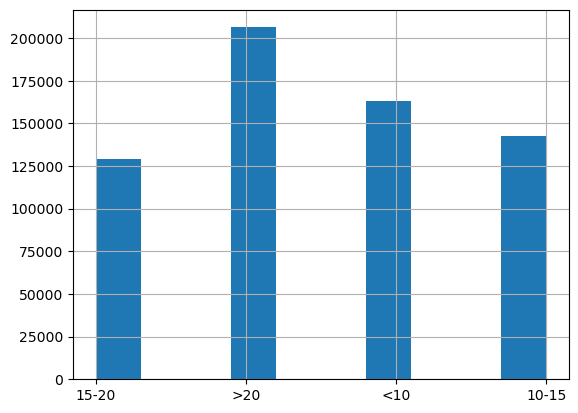

In [267]:
Pinos=DF.loc[(DF['Label']=='Pinus')]

Pinos['Range_S'].hist()

<AxesSubplot:>

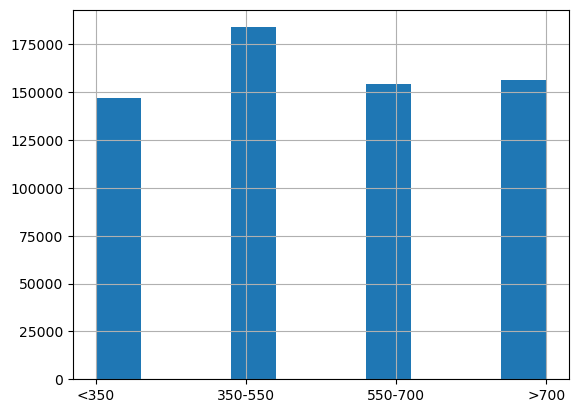

In [268]:
Pinos['Range_H'].hist()

<AxesSubplot:>

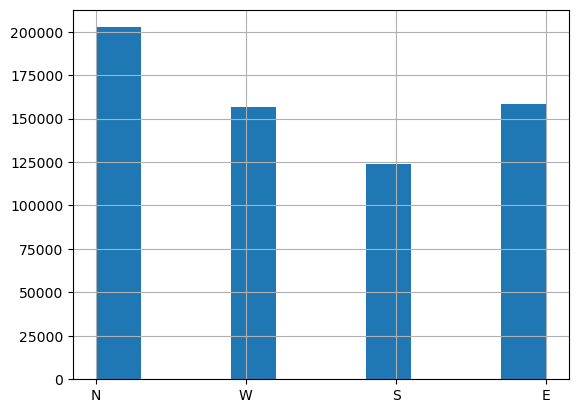

In [269]:
Pinos['Face'].hist()

<AxesSubplot:>

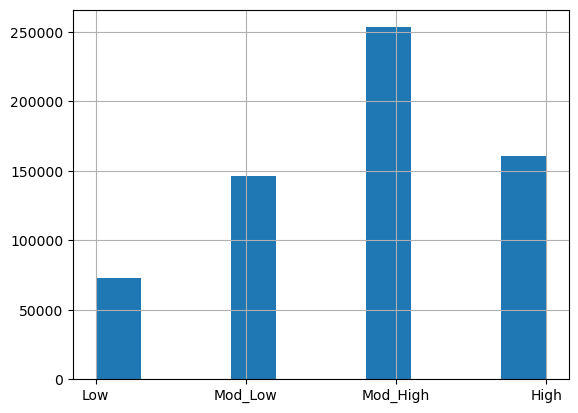

In [270]:
Pinos['Severity'].hist()

# Quercus

<AxesSubplot:>

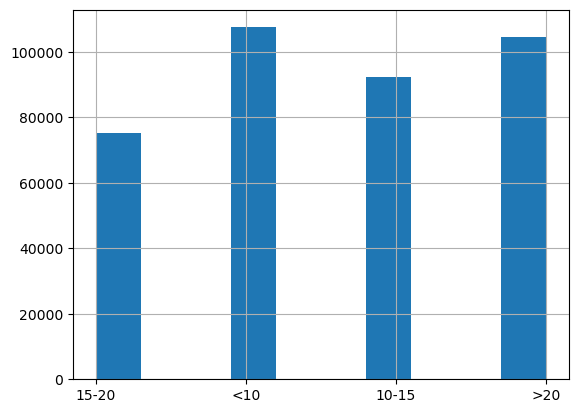

In [271]:
Quercus=DF.loc[(DF['Label']=='Quercus')]

Quercus['Range_S'].hist()

<AxesSubplot:>

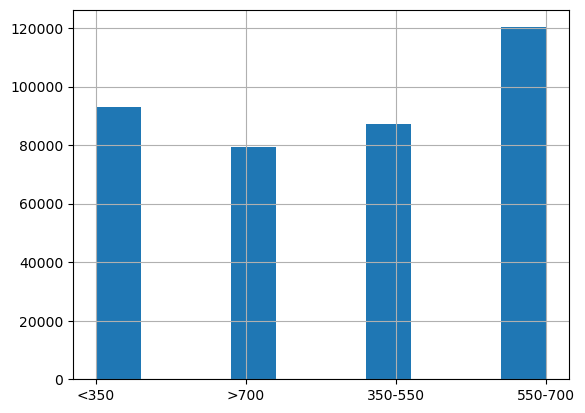

In [272]:
Quercus['Range_H'].hist()

<AxesSubplot:>

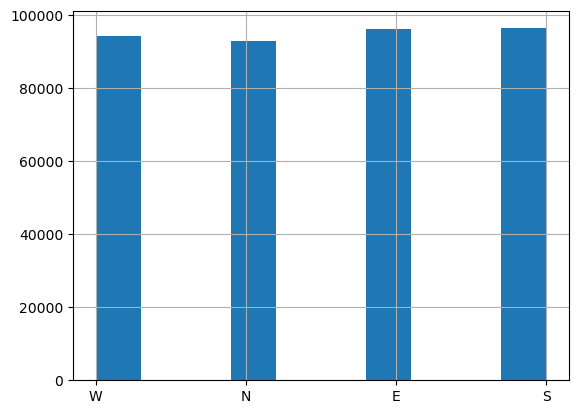

In [273]:
Quercus['Face'].hist()

<AxesSubplot:>

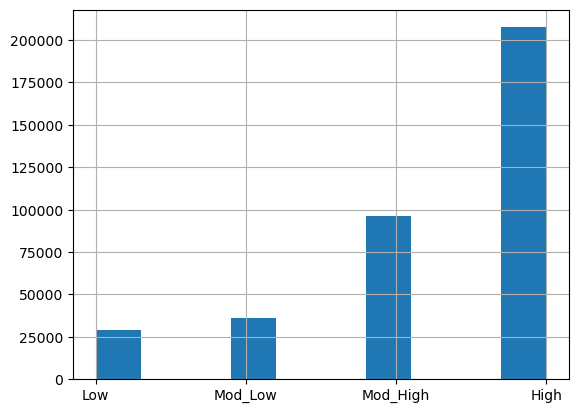

In [274]:
Quercus['Severity'].hist()

# Combinaciones

In [34]:
DF['Comb']=DF['Severity']+'_'+DF['Face']+'_'+DF['Range_S']+'_'+DF['Range_H']

In [35]:
# Navarra=DF.loc[(DF['CCAA']=='N')]

In [37]:
Pinos=DF.loc[(DF['Label']=='Pinus')]

In [41]:
Pinos

,ID_forest,Magnitude,Row,Severity,Slope,Aspect,Face,TRSI,Height,North,...,CCAA,geometry,Especie1,MFE_1985_R,ID,FECHA,Label,Range_S,Range_H,Comb
2917,4124.0,-0.178333,[7884 2071],Low,19.293010,42.277992,N,0.889403,222.0,0.244459,...,C,"MULTIPOLYGON (((0.56247 40.86169, 0.56240 40.8...",Pinus halepensis,24,41_C,1986,Pinus,15-20,<350,Low_N_15-20_<350
2918,4124.0,-0.390432,[7884 2109],Mod_Low,29.111576,271.665800,W,0.008435,413.0,0.014144,...,C,"MULTIPOLYGON (((0.56247 40.86169, 0.56240 40.8...",Pinus halepensis,24,41_C,1986,Pinus,>20,350-550,Mod_Low_W_>20_350-550
2919,4124.0,-0.432378,[7884 2110],Mod_Low,19.839088,288.304720,W,0.055205,421.0,0.106590,...,C,"MULTIPOLYGON (((0.56247 40.86169, 0.56240 40.8...",Pinus halepensis,24,41_C,1986,Pinus,15-20,350-550,Mod_Low_W_15-20_350-550
2920,4124.0,-0.306751,[7884 2111],Mod_Low,27.240501,273.605530,W,0.011812,429.0,0.028786,...,C,"MULTIPOLYGON (((0.56247 40.86169, 0.56240 40.8...",Pinus halepensis,24,41_C,1986,Pinus,>20,350-550,Mod_Low_W_>20_350-550
2921,4124.0,-0.348475,[7884 2112],Mod_Low,35.268850,267.376200,W,0.002972,445.0,-0.026432,...,C,"MULTIPOLYGON (((0.56247 40.86169, 0.56240 40.8...",Pinus halepensis,24,41_C,1986,Pinus,>20,350-550,Mod_Low_W_>20_350-550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572419,591224.0,-0.270715,[6630 3223],Mod_Low,12.977186,10.446867,N,0.665424,882.0,0.220841,...,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700,Mod_Low_N_10-15_>700
1572420,591224.0,-0.360907,[6630 3224],Mod_Low,13.231969,15.459847,N,0.706022,881.0,0.220612,...,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700,Mod_Low_N_10-15_>700
1572421,591224.0,-0.360907,[6630 3225],Mod_Low,12.821540,5.267209,N,0.622151,879.0,0.220978,...,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,10-15,>700,Mod_Low_N_10-15_>700
1572422,591224.0,-0.362523,[6630 3226],Mod_Low,15.224509,17.883074,N,0.725100,880.0,0.249914,...,V,"POLYGON ((-1.13255 39.21590, -1.13208 39.21428...",Pinus halepensis,24,5912_V,2004,Pinus,15-20,>700,Mod_Low_N_15-20_>700


In [75]:

Quercus=DF.loc[(DF['Label']=='Quercus')]

In [55]:
# nueva_ruta = 'D:\\giambelluca.144055\\Incendios\\Proyecto\\Especies\\Stat_Todo_MFE85_Pino.csv'
# Pinos.to_csv(nueva_ruta, index=False)

In [ ]:
# nueva_ruta = 'D:\\giambelluca.144055\\Incendios\\Proyecto\\Especies\\Stat_Todo_MFE85_Quercus.csv'
# Quercus.to_csv(nueva_ruta, index=False)

In [69]:
Pinos_cat=Pinos.loc[(Pinos['CCAA']=='C')]
# print(list(set(Pinos_val['ID_forest'])))

In [89]:
Quercus_val=Quercus.loc[(Quercus['CCAA']=='V')]

In [188]:
Pinos_nav

,ID_forest,Magnitude,Row,Severity,Slope,Aspect,Face,TRSI,Height,North,East,CCAA,Especie1,MFE_1985_R,ID,FECHA,Label,Range_S,Range_H,Comb
957045,30628.0,-0.378633,[2590 4906],Mod_Low,11.320534,90.00000,E,0.994016,362.0,0.424623,1.962976e-01,N,sin datos,28,306_N,1989,Pinus,10-15,350-550,Mod_Low_E_10-15_350-550
957058,30628.0,-0.273084,[2592 4906],Mod_Low,12.060480,155.39085,S,0.635600,347.0,0.057040,8.700955e-02,N,sin datos,28,306_N,1989,Pinus,10-15,<350,Mod_Low_S_10-15_<350
957059,30628.0,-0.273084,[2592 4907],Mod_Low,9.931376,157.59727,S,0.616971,344.0,-0.421638,6.573008e-02,N,sin datos,28,306_N,1989,Pinus,<10,<350,Mod_Low_S_<10_<350
957065,30628.0,-0.344843,[2593 4906],Mod_Low,11.948281,186.03368,S,0.371373,343.0,0.450693,-2.176170e-02,N,sin datos,28,306_N,1989,Pinus,10-15,<350,Mod_Low_S_10-15_<350
957066,30628.0,-0.344843,[2593 4907],Mod_Low,3.704792,180.00000,S,0.422874,343.0,0.319514,-8.699936e-08,N,sin datos,28,306_N,1989,Pinus,<10,<350,Mod_Low_S_<10_<350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992575,89239.0,-0.541853,[5116 5772],Mod_High,17.502544,150.76955,S,0.673934,694.0,-0.974712,1.468622e-01,N,sin datos,239,89_N,2004,Pinus,15-20,550-700,Mod_High_S_15-20_550-700
992576,89239.0,-0.332857,[5117 5765],Mod_Low,9.868810,242.27335,W,0.026825,703.0,0.400402,-1.517132e-01,N,sin datos,239,89_N,2004,Pinus,<10,>700,Mod_Low_W_<10_>700
992578,89239.0,-0.489704,[5117 5767],Mod_High,5.687151,192.76195,S,0.315650,705.0,0.242151,-2.189067e-02,N,sin datos,239,89_N,2004,Pinus,<10,>700,Mod_High_S_<10_>700
992579,89239.0,-0.489704,[5117 5768],Mod_High,7.470701,149.78268,S,0.681982,704.0,0.490311,6.543610e-02,N,sin datos,239,89_N,2004,Pinus,<10,>700,Mod_High_S_<10_>700


In [172]:
type(Quercus_nav)

pandas.core.frame.DataFrame

In [168]:
Quercus_nav['Row']=Quercus_nav['Row'].astype('str')

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_26320\287358745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Quercus_nav['Row']=Quercus_nav['Row'].astype('str')


In [90]:
filas=[]
columnas=[]

for i in range (len(Quercus_val)):
    rows=Quercus_val['Row'].iloc[i]
    numeros = re.findall("\d+", rows)
    fil=int(numeros[0])
    colum=int(numeros[1])
    filas.append(fil)
    columnas.append(colum)
    
Quercus_val['Rows']=filas
Quercus_val['Columns']=columnas

# print(filas)
# print(columnas)
# print(Pinos['Row'].iloc[0])

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_14768\4267661437.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Quercus_val['Rows']=filas
C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_14768\4267661437.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Quercus_val['Columns']=columnas


In [84]:
#Navarra
origen_X=-3.00001+(0.0002694945852869846275/2)
origen_Y=44.0001-(0.0002694945852869846275/2)
resolución_espacial=0.0002694945852869846275

In [91]:
#Valencia
origen_X=-2.00019+(0.0002694945852869846275/2)
origen_Y=41.0001-(0.0002694945852869846275/2)
resolución_espacial=0.0002694945852869846275

In [78]:
#Catalunia
origen_X=0+(0.0002694945852869846275/2)
origen_Y=43-(0.0002694945852869846275/2)
resolución_espacial=0.0002694945852869846275

In [92]:
Quercus_val['longitude'] = origen_X + (Quercus_val['Columns'] * resolución_espacial)
Quercus_val['latitude'] = origen_Y - (Quercus_val['Rows'] * resolución_espacial)

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_14768\2905659111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Quercus_val['longitude'] = origen_X + (Quercus_val['Columns'] * resolución_espacial)
C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_14768\2905659111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Quercus_val['latitude'] = origen_Y - (Quercus_val['Rows'] * resolución_espacial)


In [93]:
df=Quercus_val

In [94]:
geo=gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
gdf=geo.set_crs(4326, allow_override=True)
# print(gdf.crs)
ruta='D:\\giambelluca.144055\\Incendios\\Proyecto\\Especies\\Quercus_4326_Val'
gdf.to_file(ruta,driver='ESRI Shapefile')